In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import os
import re
import itertools


def get_loc_train_fmt(fname):
    # 0209-[LOC]_[ID].jpg
    return re.split(r'[-_.]', fname)[1]

def get_loc_test_fmt(fname):
     # [LOC]_[???].jpg
     return fname.split('_')[0]


def get_fnames_common_pool(root, loc, get_loc):
    return tuple(
        map(lambda x: f"{root}/{x}",
        filter(lambda x: loc == get_loc(x),
        os.listdir(root)
    )))


def mean_img(fnames):
    imgs_sum = None
    for fname in fnames:
            img: np.ndarray = cv2.imread(fname)  # type: ignore
            # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if imgs_sum is None:
                imgs_sum = np.zeros_like(img, dtype=np.float64)
            imgs_sum += img

    res = imgs_sum / len(fnames)  # type: ignore
    res = res.astype(np.uint8)
    return res

def var_img(fnames, mean=None):
    mean = mean or mean_img(fnames)
    imgs_acc = None
    for fname in fnames:
        img: np.ndarray = cv2.imread(fname)  # type: ignore
        # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if imgs_acc is None:
            imgs_acc = np.zeros_like(img, dtype=np.float64)
        imgs_acc += (img - mean)**2
    res = imgs_acc / len(fnames)  # type: ignore
    return res

def std_img(fnames, mean=None):
    return np.sqrt(var_img(fnames, mean))

def std_img_rgb(fnames, mean=None):
    std = std_img(fnames, mean)
    res = std / std.max() * 256
    res = res.astype(np.uint8)
    return res

In [4]:
TRN_PTH = "./dl-lab-2-stuff-detection/yolo_dataset/yolo_dataset/train/images"
TST_PTH = "./dl-lab-2-stuff-detection/test_images/test_images"

In [5]:
XS = (
    0, 18, 36, 54,  90, 108,  144, 162,
    198, 216,  252, 270,  306, 324
)
# RECT: XYWH
DATETIME_RECT = (0, 16, 342, 32)
NUMS_RECTS = [(xs, 20, 14, 20) for xs in XS]


def draw_rects(img, rects):
    if not isinstance(rects, list): rects = [rects]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    for rect in rects:
        x,y,w,h = rect
        pt1 = (x-1,y-1)
        pt2 = (x+w,y+h)
        cv2.rectangle(img_rgb, pt1, pt2, thickness=1, color=(255, 0, 0))
    plt.imshow(img_rgb)

def crop_rects(img, rects):
    crops = []
    for rect in rects:
        x, y, w, h = rect
        crops.append(img[y : y+h, x : x+w])
    return crops

def plot_bunch(imgs, cols=None, figsize=(15, 5)):
    n = len(imgs)
    if cols is not None:
        rows = n // cols + (n % cols != 0)
    else:
        rows = 1; cols = n
    fig, axs = plt.subplots(rows, cols, figsize=figsize)
    if n == 1: axs = [axs]
    for i, img in enumerate(imgs):
        axs[i].set_title(i)
        axs[i].imshow(img)
        axs[i].axis('off')
    plt.show()



(720, 1280, 3)


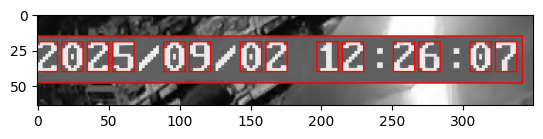

In [71]:
# img: np.ndarray = cv2.imread(f"{TRN_PTH}/0209-35_00898500.jpg")  # type: ignore
img: np.ndarray = cv2.imread(f"{TRN_PTH}/0209-2_00885400.jpg")  # type: ignore
print(img.shape)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = img[:64, :350]

draw_rects(img, NUMS_RECTS + [DATETIME_RECT])

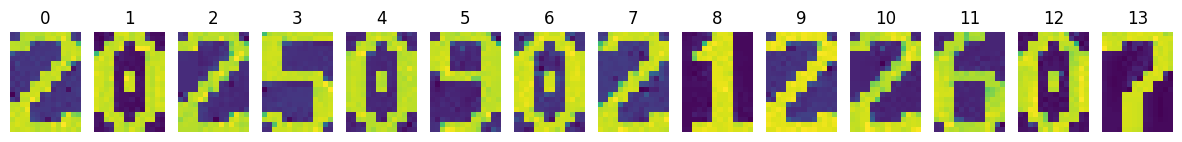

In [ ]:
plot_bunch(crop_def plot_bunch(imgs, cols=None, figsize=(15, 5)):
    n = len(imgs)
    if cols is not None:
        rows = n // cols + (n % cols != 0)
    else:
        rows = 1; cols = n
    fig, axs = plt.subplots(rows, cols, figsize=figsize)
    if n == 1: axs = [axs]
    for i, img in enumerate(imgs):
        axs[i].set_title(i)
        axs[i].imshow(img)
        axs[i].axis('off')
    plt.show()rects(img, NUMS_RECTS))

In [30]:
def get_nums(img):
    crops = np.zeros((14, 20, 14), dtype=np.byte)
    for i, rect in enumerate(NUMS_RECTS):
        x, y, w, h = rect
        crops[i] = (img[y : y+h, x : x+w] / 256) > 0.7
    return crops

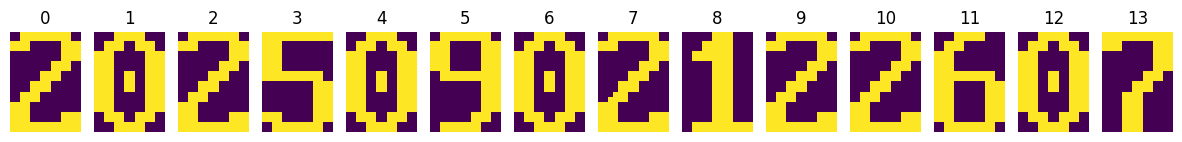

In [57]:
plot_bunch(get_nums(img))

In [59]:
nums = get_nums(img)

In [62]:
nums[13].shape

(20, 14)

<Axes: >

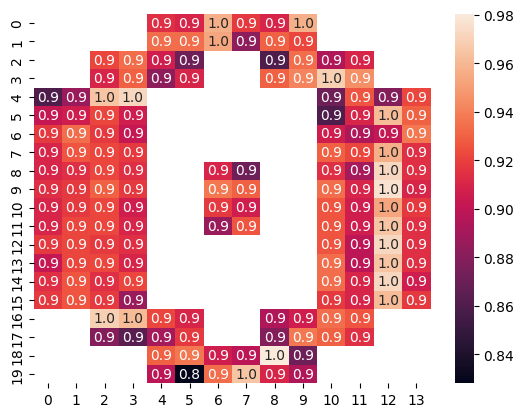

In [ ]:
nums = crop_rects(img, NUMS_RECTS)
nn = []
for num in nums:
    n = np.zeros_like(num, dtype=np.float16)
    n = num / 256
    nn.append(n)

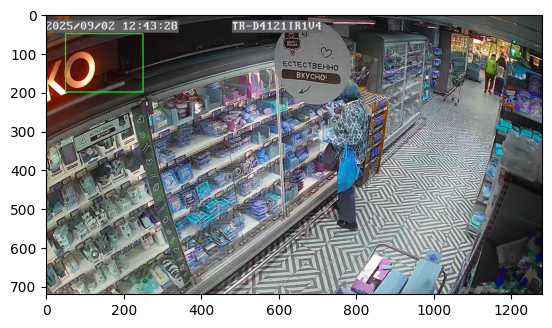

In [4]:

pt1 = (50, 50)
pt2 = (50 + 200, 50 + 150)
color = (0, 255, 0) # Зеленый цвет (BGR)
thickness = 2       # Толщина линии

# Рисуем
cv2.rectangle(img, pt1, pt2, color, thickness)
plt.imshow(img)

(150, 200, 3)

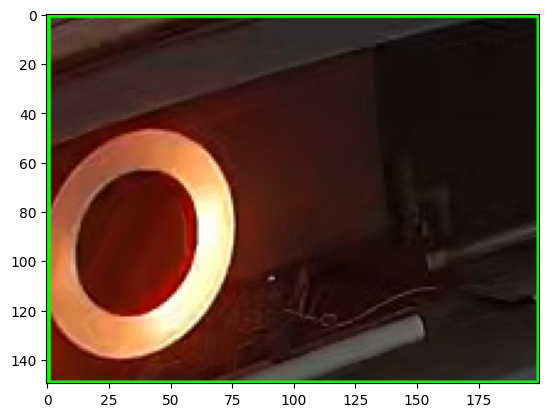

In [6]:
# Координаты (те же, что выше)
x, y, w, h = 50, 50, 200, 150

# Вырезаем (crop)
# Используем срез: [y_start:y_end, x_start:x_end]
crop_img = img[y : y+h, x : x+w]
display(crop_img.shape)
plt.imshow(crop_img)

In [63]:
nums = [
np.array([[0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]], dtype=np.uint8),
np.array([[0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.uint8),
np.array([[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.uint8),
np.array([[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]], dtype=np.uint8),
np.array([[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=np.uint8),
np.array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]], dtype=np.uint8),
np.array([[0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]], dtype=np.uint8),
np.array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]], dtype=np.uint8),
np.array([[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]], dtype=np.uint8),
np.array([[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]], dtype=np.uint8),
]

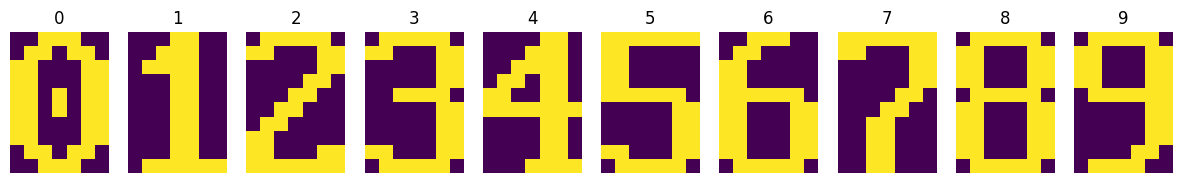

In [64]:
plot_bunch(nums)

In [65]:
flat_nums = np.concatenate([m.flatten() for m in nums]).astype(np.uint8)
packed = np.packbits(flat_nums)
packed.tofile('./digits-font.bin')

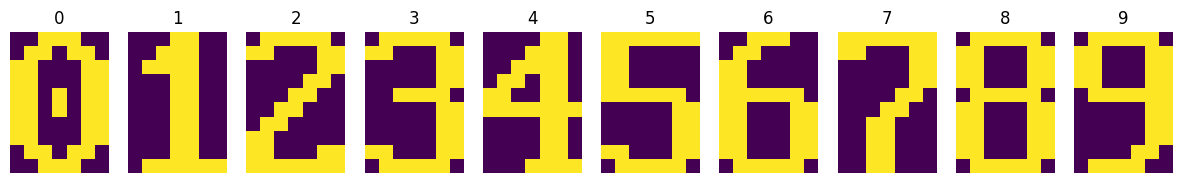

In [6]:
loaded_packed = np.fromfile('digits-font.bin', dtype=np.uint8)
bits = np.unpackbits(loaded_packed)[:2800]
matrices = bits.reshape(10, 20, 14)
plot_bunch(matrices)

In [7]:
matrices.shape

(10, 20, 14)